In [1]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 988.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [36]:
import mlflow
import mlflow.sklearn

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score

In [12]:
import pandas as pd

df = pd.read_csv("/content/Curriculum_Industry_Skill_Alignment.csv")

X = df[
    [
        "CGPA",
        "Programming",
        "DSA",
        "DBMS",
        "OS",
        "CN",
        "OOP",
        "Python",
        "Java",
        "SQL",
        "Web_Development",
        "Cloud",
        "AI_ML",
        "Communication",
        "Aptitude",
        "Teamwork",
        "Problem_Solving",
        "Internship",
        "Certifications",
        "Projects_Completed",
        "Gender"
    ]
]

y = df["Industry_Readiness"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
numerical_features = [
    "CGPA",
    "Programming",
    "DSA",
    "DBMS",
    "OS",
    "CN",
    "OOP",
    "Python",
    "Java",
    "SQL",
    "Web_Development",
    "Cloud",
    "AI_ML",
    "Communication",
    "Aptitude",
    "Teamwork",
    "Problem_Solving",
    "Certifications",
    "Projects_Completed"
]

categorical_features = [
    "Gender",
    "Internship"
]

In [16]:
numerical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="median")),
        ("scaling", StandardScaler())
    ]
)

In [17]:
categorical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="most_frequent")),
        ("encoding", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [19]:
mlflow.set_experiment(
    "Industry Readiness Prediction"
)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1787552325312, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787552325312, lifecycle_stage='active', name='Industry Readiness Prediction', tags={}, trace_location=None, workspace='default'>

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import mlflow
import mlflow.sklearn

In [21]:
with mlflow.start_run(run_name="Logistic Regression"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    max_iter=1000
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("C", 1.0)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Logistic Regression Accuracy:", accuracy)

2026/08/24 06:22:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Accuracy: 0.95


In [22]:
with mlflow.start_run(run_name="Decision Tree"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Decision Tree Accuracy:", accuracy)

2026/08/24 06:23:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree Accuracy: 0.95


In [23]:
with mlflow.start_run(run_name="Random Forest"):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(X_train, y_train)

    predictions = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )

    print("Random Forest Accuracy:", accuracy)

2026/08/24 06:24:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Accuracy: 0.95


In [37]:
models = {
    "LogisticRegression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight="balanced"
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight="balanced",
    ),
}

In [25]:
for model_name, model in models.items():

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline(
            steps=[
                ("preprocessing", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        mlflow.log_param(
            "model",
            model_name
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )

        print(
            model_name,
            "Accuracy:",
            accuracy
        )

2026/08/24 06:24:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/24 06:25:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression Accuracy: 0.95
DecisionTree Accuracy: 0.95


2026/08/24 06:25:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.95


In [27]:
import mlflow

mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

mlflow.set_experiment(
      "Industry Readiness Prediction"
)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:////content/mlflow.db


In [28]:
experiment = mlflow.get_experiment_by_name(
      "Industry Readiness Prediction"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "metrics.accuracy"
    ]
].sort_values(
    "metrics.accuracy",
    ascending=False
)

comparison

,tags.mlflow.runName,params.model,metrics.accuracy
0,RandomForest,RandomForest,0.95
1,DecisionTree,DecisionTree,0.95
2,LogisticRegression,LogisticRegression,0.95
3,Random Forest,RandomForest,0.95
4,Decision Tree,DecisionTree,0.95
5,Logistic Regression,LogisticRegression,0.95
6,Logistic Regression,None,NaN


In [38]:
for model_name, model in models.items():

  with mlflow.start_run(run_name=model_name):

    pipeline = Pipeline(
        steps=[("preprocessing", preprocessor), ("model", model)]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, pos_label="Ready")

    # Log parameters and metrics
    mlflow.log_param("model", model_name)
    mlflow.log_params(model.get_params())
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(
        sk_model=pipeline, name="model", serialization_format="cloudpickle"
    )

    print(f"{model_name} -> Accuracy: {accuracy:.2f} | F1-Score: {f1:.2f}")

2026/08/24 06:35:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression -> Accuracy: 0.95 | F1-Score: 0.00


2026/08/24 06:36:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree -> Accuracy: 0.85 | F1-Score: 0.00


2026/08/24 06:36:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest -> Accuracy: 0.95 | F1-Score: 0.00


In [39]:
experiment = mlflow.get_experiment_by_name(
      "Industry Readiness Prediction"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,metrics.f1_score,params.verbose,params.bootstrap,...,params.penalty,params.C,params.dual,params.multi_class,params.l1_ratio,params.intercept_scaling,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.source.name
0,03c124e2e044481094a26aff5e0d481e,1,FINISHED,/content/mlruns/1/03c124e2e044481094a26aff5e0d...,2026-08-24 06:36:07.197000+00:00,2026-08-24 06:36:12.432000+00:00,0.95,0.0,0,True,...,None,None,None,None,None,None,root,NOTEBOOK,RandomForest,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
1,9704b805d73145fe9db3574b369e8b5f,1,FINISHED,/content/mlruns/1/9704b805d73145fe9db3574b369e...,2026-08-24 06:36:02.587000+00:00,2026-08-24 06:36:07.182000+00:00,0.85,0.0,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,DecisionTree,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
2,03bbb5de18e747a5be542ccf5c880f4c,1,FINISHED,/content/mlruns/1/03bbb5de18e747a5be542ccf5c88...,2026-08-24 06:35:53.996000+00:00,2026-08-24 06:36:02.570000+00:00,0.95,0.0,0,None,...,l2,1.0,False,deprecated,None,1,root,NOTEBOOK,LogisticRegression,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
3,b837860fbeee4bd6ad5642354c037eb2,1,FINISHED,/content/mlruns/1/b837860fbeee4bd6ad5642354c03...,2026-08-24 06:28:20.998000+00:00,2026-08-24 06:28:26.906000+00:00,0.95,NaN,0,True,...,None,None,None,None,None,None,root,NOTEBOOK,RandomForest,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
4,af6f932aa7c341f4bfa55cad80315b9f,1,FINISHED,/content/mlruns/1/af6f932aa7c341f4bfa55cad8031...,2026-08-24 06:28:14.543000+00:00,2026-08-24 06:28:20.980000+00:00,0.95,NaN,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,DecisionTree,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
5,8c37e1769889488d9dc59a2e2a50fa37,1,FINISHED,/content/mlruns/1/8c37e1769889488d9dc59a2e2a50...,2026-08-24 06:27:57.157000+00:00,2026-08-24 06:28:14.510000+00:00,0.95,NaN,0,None,...,l2,1.0,False,deprecated,None,1,root,NOTEBOOK,LogisticRegression,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
6,195a341529174ed19322065fec18ee6a,1,FINISHED,/content/mlruns/1/195a341529174ed19322065fec18...,2026-08-24 06:25:10.899000+00:00,2026-08-24 06:25:15.560000+00:00,0.95,NaN,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,RandomForest,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
7,6c1a7622c0c3456181f898fa929bebc4,1,FINISHED,/content/mlruns/1/6c1a7622c0c3456181f898fa929b...,2026-08-24 06:25:06.425000+00:00,2026-08-24 06:25:10.883000+00:00,0.95,NaN,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,DecisionTree,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
8,e0718fb3d7ba47dda431febd6b62e425,1,FINISHED,/content/mlruns/1/e0718fb3d7ba47dda431febd6b62...,2026-08-24 06:24:58.750000+00:00,2026-08-24 06:25:06.408000+00:00,0.95,NaN,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,LogisticRegression,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV
9,2928659fdffe404a9336e8a4f7300c38,1,FINISHED,/content/mlruns/1/2928659fdffe404a9336e8a4f730...,2026-08-24 06:24:29.335000+00:00,2026-08-24 06:24:34.119000+00:00,0.95,NaN,None,None,...,None,None,None,None,None,None,root,NOTEBOOK,Random Forest,fileId=1Pxx9UrvdIUHbmKnnsAMybZOo8rLuDywV


In [45]:
comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy",
        "metrics.f1_score",
    ]
].sort_values("metrics.f1_score", ascending=False)

comparison

,tags.mlflow.runName,params.model,params.C,params.max_depth,params.n_estimators,metrics.accuracy,metrics.f1_score
0,RandomForest,RandomForest,None,5,100,0.95,0.0
1,DecisionTree,DecisionTree,None,5,None,0.85,0.0
2,LogisticRegression,LogisticRegression,1.0,None,None,0.95,0.0
3,RandomForest,RandomForest,None,5,100,0.95,NaN
4,DecisionTree,DecisionTree,None,5,None,0.95,NaN
5,LogisticRegression,LogisticRegression,1.0,None,None,0.95,NaN
6,RandomForest,RandomForest,None,None,None,0.95,NaN
7,DecisionTree,DecisionTree,None,None,None,0.95,NaN
8,LogisticRegression,LogisticRegression,None,None,None,0.95,NaN
9,Random Forest,RandomForest,None,5,100,0.95,NaN


In [46]:
import pandas as pd

comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy",
        "metrics.f1_score",
    ]
].copy()

comparison.columns = [
    "Run Name",
    "Model",
    "C",
    "Max Depth",
    "No. of Trees",
    "Accuracy",
    "F1-Score",
]

comparison = comparison.dropna(subset=["Model", "Accuracy", "F1-Score"])

comparison["Accuracy"] = (comparison["Accuracy"] * 100).round(2)
comparison["F1-Score"] = (comparison["F1-Score"] * 100).round(2)

comparison = comparison.sort_values("F1-Score", ascending=False)

comparison

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy,F1-Score
0,RandomForest,RandomForest,None,5,100,95.0,0.0
1,DecisionTree,DecisionTree,None,5,None,85.0,0.0
2,LogisticRegression,LogisticRegression,1.0,None,None,95.0,0.0


In [47]:
best_models = (
    comparison.sort_values(["F1-Score", "Accuracy"], ascending=[False, False])
    .drop_duplicates(subset=["Model"])
    .reset_index(drop=True)
)

best_models

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy,F1-Score
0,RandomForest,RandomForest,None,5,100,95.0,0.0
1,LogisticRegression,LogisticRegression,1.0,None,None,95.0,0.0
2,DecisionTree,DecisionTree,None,5,None,85.0,0.0


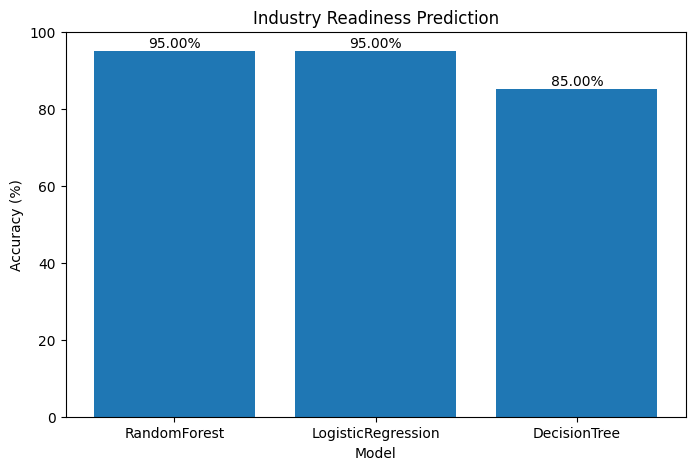

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    best_models["Model"],
    best_models["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title(  "Industry Readiness Prediction")

plt.ylim(0, 100)

for i, value in enumerate(best_models["Accuracy"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [49]:
display(
    best_models[
        [
            "Model",
            "C",
            "Max Depth",
            "No. of Trees",
            "Accuracy"
        ]
    ].style
    .format({"Accuracy": "{:.2f}%"})
    .highlight_max(
        subset=["Accuracy"],
        axis=0
    )
)

,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,None,5,100,95.00%
1,LogisticRegression,1.0,None,None,95.00%
2,DecisionTree,None,5,None,85.00%
